In [1]:
# Tự nạp lại raw_feature.py mỗi khi sửa, không cần restart kernel
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from feature_edge import compute_edge_feature

In [2]:
# Load split-index, dựng src/dest, lấy TRAN train (quyết định cột chỉ trên train)
dtype = {"From Bank": str, "Account": str, "To Bank": str, "Account.1": str}
df = pd.read_csv("dataset_high/HI-Small_Trans_split_index.csv", dtype=dtype)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["src"]  = df["From Bank"] + " | " + df["Account"]
df["dest"] = df["To Bank"]   + " | " + df["Account.1"]

train = df[df["split"] == "train"]
feat = compute_edge_feature(train)
print("feat shape:", feat.shape)

feat shape: (936373, 13)


In [ ]:
n = len(feat)
c = feat["num_tx"]

dist = (
    c.value_counts()
     .sort_index()
     .rename("count")
     .to_frame()
     .assign(
         pct=lambda d: d["count"] / n * 100,
         cumsum_pct=lambda d: d["count"].cumsum() / n * 100,
     )
     .round(2)
)
print("Phân phối num_tx (10 mức đầu):")
print(dist.head(10))

print(f"\nTổng hợp số giao dịch của 1 tài khoản: {n:,}")
print(f"num_tx == 1        : {(c == 1).mean()*100:.1f}%   -> 1 cạnh giao dịch nên các chỉ số median=mean=min=max ")
print(f"num_tx <= 2        : {(c <= 2).mean()*100:.1f}%")
print(f"num_tx <  3 (skew NaN)     : {(c < 3).mean()*100:.1f}%   # skew cần >= 3 điểm")
print(f"num_tx <  4 (kurtosis NaN) : {(c < 4).mean()*100:.1f}%   # kurtosis cần >= 4 điểm")

Phân phối num_tx (10 mức đầu):
         count    pct  cum_pct
num_tx                        
1       470960  50.30    50.30
2       201653  21.54    71.83
3        43205   4.61    76.45
4        25043   2.67    79.12
5         9975   1.07    80.19
6        40809   4.36    84.54
7         1098   0.12    84.66
8        42627   4.55    89.21
9         8836   0.94    90.16
10       22208   2.37    92.53

Tổng số cạnh: 936,373
num_tx == 1        : 50.3%   -> 1 cạnh giao dịch nên các chỉ số median=mean=min=max 
num_tx <= 2        : 71.8%
num_tx <  3 (skew NaN)     : 71.8%   # skew cần >= 3 điểm
num_tx <  4 (kurtosis NaN) : 76.4%   # kurtosis cần >= 4 điểm


In [4]:
# ── Thực nghiệm: amt_ratio có phụ thuộc hoàn toàn vào cặp tiền không? ──
# Chạy trên giao dịch thô (train), vì amt_ratio là đại lượng của TỪNG giao dịch.
t = train[train["Amount Received"] > 0].copy()
t["amt_ratio"] = t["Amount Paid"] / t["Amount Received"]
t["cur_pair"]  = t["Payment Currency"].astype(str) + "->" + t["Receiving Currency"].astype(str)

g = t.groupby("cur_pair")["amt_ratio"]
stats = pd.DataFrame({"count": g.count(), "mean": g.mean(), "std": g.std()})
stats["cv"] = stats["std"] / stats["mean"]          # hệ số biến thiên: bỏ ảnh hưởng độ lớn tỷ giá
stats = stats[stats["count"] >= 30].sort_values("cv", ascending=False)

print(stats.head(15).round(4))
med_cv = stats["cv"].median()
print(f"\nCV trung vị = {med_cv:.4f}")
print("=> amt_ratio bị cặp tiền quyết định hoàn toàn → TRÙNG currency proportion, nên BỎ."
      if med_cv < 0.01 else
      "=> amt_ratio còn dao động trong cùng cặp tiền → có thông tin mới, nên GIỮ (nhớ log1p).")

                              count        mean         std      cv
cur_pair                                                           
US Dollar->Bitcoin              833  11901.7459   1863.0107  0.1565
Yuan->Bitcoin                    80  74599.3660  10083.1622  0.1352
Canadian Dollar->Swiss Franc     36      1.4505      0.0955  0.0658
Euro->Bitcoin                   142  10144.1952    550.0176  0.0542
Ruble->US Dollar                 88     77.4282      3.7126  0.0479
Australian Dollar->US Dollar     79      1.4202      0.0661  0.0465
Brazil Real->US Dollar           44      5.6774      0.2040  0.0359
UK Pound->Bitcoin                59   9323.6592    290.8838  0.0312
Yen->US Dollar                  581    105.1980      3.0305  0.0288
Yuan->Brazil Real                31      1.1801      0.0334  0.0283
Mexican Peso->US Dollar         162     21.1828      0.5414  0.0256
Canadian Dollar->US Dollar      318      1.3175      0.0257  0.0195
Swiss Franc->Euro                44      1.0689 

In [5]:
# Profile mọi cột để TỰ quyết định nhóm (thay cho việc hardcode ratio_cols/special)
profile = pd.DataFrame({
    "min":     feat.min(),
    "max":     feat.max(),
    "pct_neg": (feat < 0).mean() * 100,        # % giá trị âm -> >0 nghĩa là không dùng được log1p
    "in_0_1":  (feat.min() >= 0) & (feat.max() <= 1),  # True = ratio nằm gọn trong [0,1]
    "skew":    feat.skew(),
}).round(3)

print("== Cột nằm trong [0,1] (ứng viên ratio_cols) ==")
print(profile.index[profile["in_0_1"]].tolist())
print("\n== Cột có giá trị âm (ứng viên special) ==")
print(profile.index[profile["pct_neg"] > 0].tolist())
print("\n== Bảng đầy đủ ==")
profile.sort_values("skew", ascending=False)

== Cột nằm trong [0,1] (ứng viên ratio_cols) ==
['cross_ccy_ratio', 'round_ratio', 'is_cross_bank', 'is_self_loop', 'is_edge_mule']

== Cột có giá trị âm (ứng viên special) ==
[]

== Bảng đầy đủ ==


,min,max,pct_neg,in_0_1,skew
std_paid,0.0,3.293114e+11,0.0,False,496.384
max_paid,0.0,6.260355e+11,0.0,False,467.428
total_paid,0.0,1.013024e+12,0.0,False,430.206
mean_paid,0.0,3.376745e+11,0.0,False,415.677
min_paid,0.0,9.876640e+10,0.0,False,253.144
round_ratio,0.0,1.000000e+00,0.0,True,195.978
is_edge_mule,0.0,1.000000e+00,0.0,True,20.520
cross_ccy_ratio,0.0,1.000000e+00,0.0,True,11.542
num_tx,1.0,4.900000e+01,0.0,False,2.373
tx_per_day,0.4,9.800000e+00,0.0,False,1.877


In [6]:
# Bảng skew: thô vs sau log1p
ratio_cols=[]
for i in profile.index:
    if profile.loc[i,"in_0_1"]==True:
        ratio_cols.append(i)
cand   = [c for c in feat.columns if c not in ratio_cols]              #cand là cột chứa cột cần xử lý
nonneg = [c for c in cand if feat[c].min() >= 0]                                 # log1p chỉ hợp lệ khi >= 0
report = pd.DataFrame({
    "min":        feat[cand].min(),
    "skew_raw":   feat[cand].skew(),
    "skew_log1p": np.log1p(feat[nonneg]).skew(),
}).sort_values("skew_raw", ascending=False)

report.round(2)

,min,skew_raw,skew_log1p
std_paid,0.0,496.38,0.90
max_paid,0.0,467.43,0.17
total_paid,0.0,430.21,0.05
mean_paid,0.0,415.68,0.20
min_paid,0.0,253.14,0.41
num_tx,1.0,2.37,1.25
tx_per_day,0.4,1.88,1.01
active_day,1.0,1.42,1.32


In [7]:
# Đề xuất cột log1p (lệch phải mạnh + không âm). Vẫn nên nhìn skew_log1p để loại cột bị kéo quá đà.
log1p_cols = report.index[(report["skew_raw"] > 1) & (report["min"] >= 0)].tolist()
print("Đề xuất log1p_cols:")
for c in log1p_cols:
    print(f"  {c:18s} skew_raw={report.loc[c,'skew_raw']:.2f} -> skew_log1p={report.loc[c,'skew_log1p']:.2f}")

Đề xuất log1p_cols:
  std_paid           skew_raw=496.38 -> skew_log1p=0.90
  max_paid           skew_raw=467.43 -> skew_log1p=0.17
  total_paid         skew_raw=430.21 -> skew_log1p=0.05
  mean_paid          skew_raw=415.68 -> skew_log1p=0.20
  min_paid           skew_raw=253.14 -> skew_log1p=0.41
  num_tx             skew_raw=2.37 -> skew_log1p=1.25
  tx_per_day         skew_raw=1.88 -> skew_log1p=1.01
  active_day         skew_raw=1.42 -> skew_log1p=1.32


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11180\2610458739.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feat[col], np.log1p(feat[col])], labels=["raw", "log1p"])


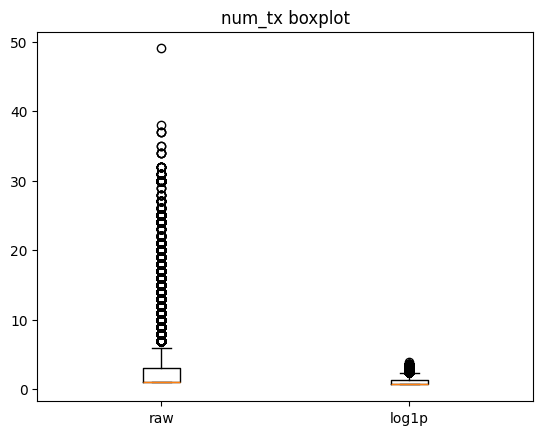

In [8]:
col = "num_tx"
plt.boxplot([feat[col], np.log1p(feat[col])], labels=["raw", "log1p"])
plt.title(f"{col} boxplot"); plt.show()